In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

In [2]:
df = pd.read_csv('data/V-Dem-CY-Core-v15.csv')
print(df.shape)


(27913, 1818)


In [3]:
years_to_keep = [2023]

# Filter dataframe to keep only selected years
df_filtered = df[df['year'].isin(years_to_keep)].reset_index(drop=True)
print(df_filtered.shape)

(179, 1818)


In [4]:
columns_to_keep = ['country_name', 'country_text_id', 'country_id', 'year', 
                   'v2x_polyarchy', 'v2x_api', 'v2x_mpi', 'v2x_frassoc_thick',
                   'v2x_suffr', 'v2xel_frefair', 'v2x_elecoff',
                   'v2x_libdem', 'v2x_polyarchy', 'v2x_liberal', 'v2xcl_rol',
                   'v2x_jucon', 'v2xlg_legcon', 
                   'v2x_partipdem', 'v2x_polyarchy', 'v2x_partip', 'v2x_cspart',
                   'v2xdd_dd', 'v2xel_locelec', 'v2xel_regelec', 
                   'v2x_delibdem', 'v2x_polyarchy', 'v2xdl_delib', 
                   'v2x_egaldem', 'v2x_polyarchy', 'v2x_egal', 'v2xeg_eqprotec',
                   'v2xeg_eqaccess', 'v2xeg_eqdr', 
                   'v2x_regime', 'v2x_elecreg', 'v2xex_elecreg', 
                   'v2x_polyarchy', 'v2x_liberal', 'v2x_accountability',
                   'v2x_diagacc', 'v2x_horacc', 'v2x_ex_confidence', 'v2x_ex_direlect',
                   'v2x_ex_hereditary', 'v2x_ex_military', 'v2x_ex_party', 'v2x_neopat',
                   'v2xnp_client', 'v2xnp_pres', 'v2xnp_regcorr', 'v2x_civlib', 'v2x_clphy',
                   'v2x_clpol', 'v2x_clpriv', 'v2xpe_exlecon', 'v2xpe_exlgender', 'v2xpe_exlgeo',
                   'v2xpe_exlpol', 'v2xpe_exlsocgr', 'v2x_corr', 'v2x_execorr', 'v2x_pubcorr',
                   'v2x_gender', 'v2x_gencl', 'v2x_gencs', 'v2x_genpp', 'v2x_rule', 'v2xdd_cic',
                   'v2xdd_i_ci', 'v2xdd_i_rf', 'v2xdd_toc', 'v2xdd_i_pl', 'v2xdd_i_or', 'v2xcs_ccsi',
                   'v2x_elecreg', 'v2xel_elecparl', 'v2xlg_leginter', 'v2xel_elecpres', 'v2x_hosinter',
                   'v2x_hosabort', 'v2x_legabort', 'v2xex_elecreg', 'v2xel_elecpres', 'v2x_hosinter', 'v2x_hosabort',
                   'v2xlg_elecreg', 'v2xel_elecparl', 'v2xlg_leginter', 'v2x_legabort', 'v2x_EDcomp_thick',
                   'v2x_frassoc_thick', 'v2xex_elecleg', 'v2x_freexp', 'v2xme_altinf', 'v2xcl_disc',
                   'v2xcl_acjst', 'v2xcl_prpty', 'v2xcl_slave', 'v2xcl_slave', 'v2xps_party',
                   'v2x_feduni', 'v2xca_academ']

df = df_filtered[columns_to_keep]
print(df.shape)
df.head()

(179, 102)


,country_name,country_text_id,country_id,year,v2x_polyarchy,v2x_api,v2x_mpi,v2x_frassoc_thick,v2x_suffr,v2xel_frefair,...,v2x_freexp,v2xme_altinf,v2xcl_disc,v2xcl_acjst,v2xcl_prpty,v2xcl_slave,v2xcl_slave,v2xps_party,v2x_feduni,v2xca_academ
0,Mexico,MEX,3,2023,0.549,0.770,0.327,0.734,1.0,0.689,...,0.614,0.729,0.803,0.339,0.825,0.608,0.608,0.743,0.990,0.645
1,Suriname,SUR,4,2023,0.768,0.897,0.639,0.865,1.0,0.863,...,0.877,0.859,0.918,0.910,0.839,0.799,0.799,0.691,0.472,0.861
2,Sweden,SWE,5,2023,0.881,0.950,0.812,0.917,1.0,0.947,...,0.953,0.918,0.898,0.964,0.932,0.948,0.948,0.995,0.948,0.940
3,Switzerland,CHE,6,2023,0.887,0.953,0.822,0.920,1.0,0.933,...,0.981,0.936,0.970,0.989,0.932,0.932,0.932,0.908,0.997,0.854
4,Ghana,GHA,7,2023,0.664,0.844,0.483,0.878,1.0,0.656,...,0.883,0.812,0.917,0.734,0.848,0.744,0.744,0.730,0.151,0.788


In [5]:
# Drop rows with na
df_clean = df.dropna()
print("Records dropped: ", df.shape[0] - df_clean.shape[0])




Records dropped:  15


In [6]:
# Remove identifiers from the features
identifiers = df_clean[['country_name', 'country_text_id', 'country_id', 'year']]

# Keep only the features for similarity analysis
features = df_clean.drop(columns=['country_name', 'country_text_id', 'country_id', 'year'])

print(features.shape)


(164, 98)


In [ ]:
# Find the columns that need normaliztion

# Compute range and standard deviation for each feature
desc = features.describe().T
desc['range'] = desc['max'] - desc['min']

# Define a threshold for "suspiciously large" range
range_threshold = desc['range'].median() * 2
std_threshold = desc['std'].median() * 2

# Flag columns that exceed either threshold
needs_normalization = desc[(desc['range'] > range_threshold) | (desc['std'] > std_threshold)]

print("Columns that likely need normalization or scaling:")
print(needs_normalization[['mean', 'std', 'min', 'max', 'range']])


Columns that likely need normalization or scaling:
                        mean       std    min    max  range
v2x_regime          1.573171  0.953270  0.000  3.000  3.000
v2x_accountability  0.615677  0.854892 -1.586  1.988  3.574
v2x_diagacc         0.588018  0.870985 -2.009  2.048  4.057
v2x_horacc          0.414280  0.982597 -2.028  2.310  4.338
v2xdd_i_pl          0.388476  0.561542  0.000  2.000  2.000
v2xdd_i_or          0.324476  0.499783  0.000  2.000  2.000


In [8]:
# Normalize the features using MinMaxScaler

columns_to_scale = ['v2x_regime', 'v2x_accountability', 'v2x_diagacc', 
                    'v2x_horacc', 'v2xdd_i_pl', 'v2xdd_i_or']

# Make a copy to avoid overwriting
features_normalized = features.copy()

# Apply MinMaxScaler to only those columns
scaler = MinMaxScaler()
features_normalized[columns_to_scale] = scaler.fit_transform(features[columns_to_scale])



In [9]:
# Check if all columns look good after scaling

# Compute range and standard deviation for each feature
desc = features_normalized.describe().T
desc['range'] = desc['max'] - desc['min']

# Define a threshold for "suspiciously large" range or std (tweakable)
range_threshold = desc['range'].median() * 2
std_threshold = desc['std'].median() * 2

# Flag columns that exceed either threshold
needs_normalization = desc[(desc['range'] > range_threshold) | (desc['std'] > std_threshold)]

print("Columns that likely need normalization or scaling:")
print(needs_normalization[['mean', 'std', 'min', 'max', 'range']])

Columns that likely need normalization or scaling:
Empty DataFrame
Columns: [mean, std, min, max, range]
Index: []


In [ ]:
#FInd K vlaue using Elbow Method and Silhouette Analysis

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use normalized feature matrix
X = features_normalized

# Range of k values to test
k_range = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))



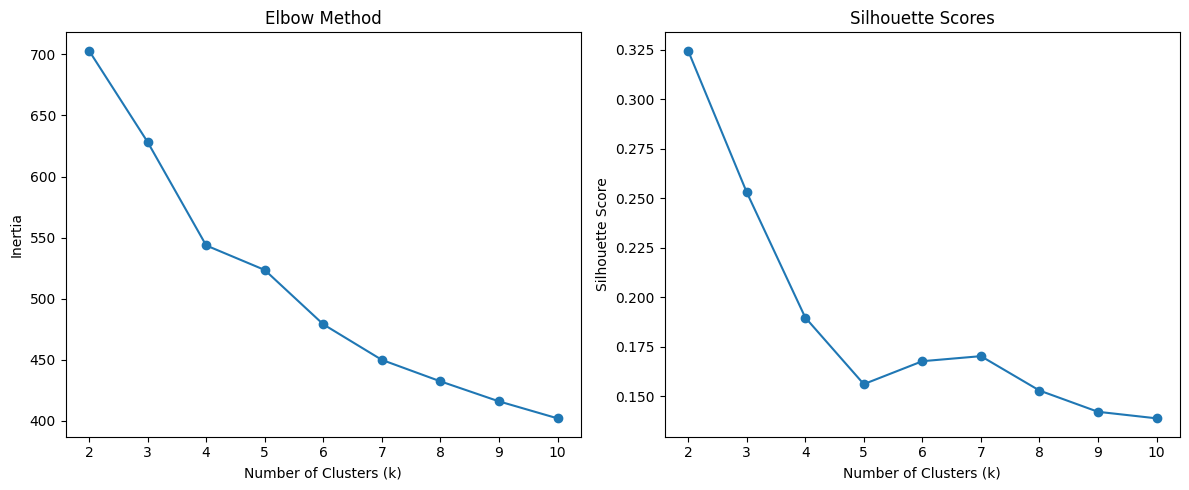

In [11]:
# Plotting results
plt.figure(figsize=(12, 5))

# Elbow plot
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

# Silhouette score plot
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

The Elbow Method suggested a clear flattening of inertia at k = 4, indicating diminishing returns with additional clusters. Meanwhile, the Silhouette Scores peaked at k = 2, but quickly stabilized between k = 4 and 6, suggesting those values offer a reasonable trade-off between cohesion and separation.


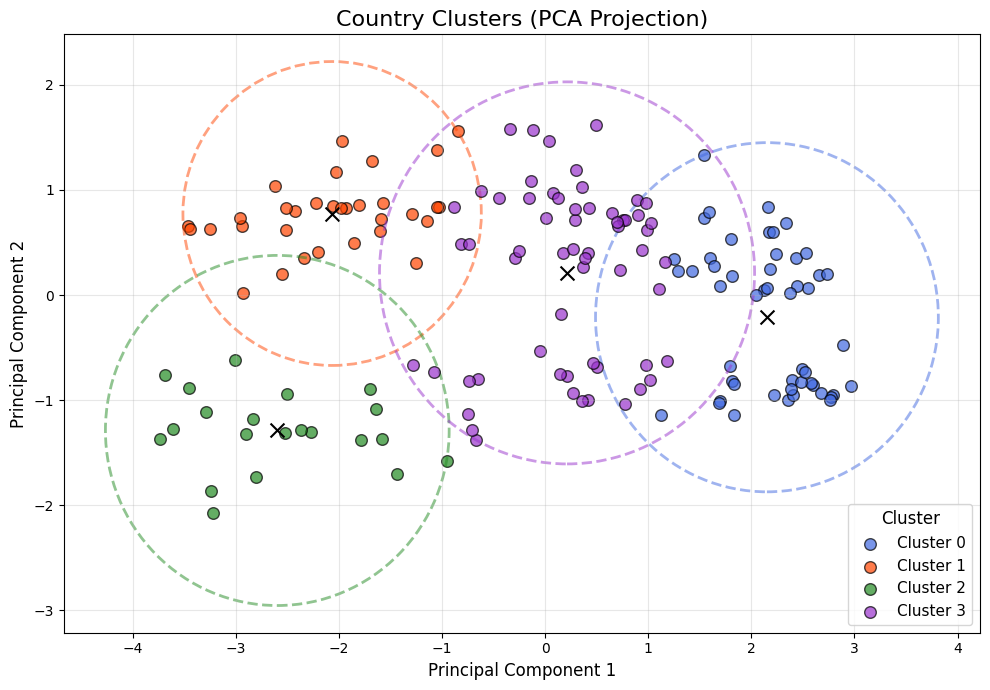

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# KMeans clustering
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(features_normalized)

# Add cluster labels 
identifiers_with_clusters = identifiers.copy()
identifiers_with_clusters['cluster'] = clusters

# Reduce dimensionality for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(features_normalized)

colors = ['royalblue', 'orangered', 'forestgreen', 'darkorchid']

plt.figure(figsize=(10, 7))

# Plot clusters and calculate cluster centers and radii
for cluster_id in range(k):
    cluster_points = X_pca[clusters == cluster_id]
    
    center = cluster_points.mean(axis=0)
    
    distances = np.linalg.norm(cluster_points - center, axis=1)
    radius = distances.max()
    
    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        s=70,
        c=colors[cluster_id],
        label=f'Cluster {cluster_id}',
        edgecolors='k',
        alpha=0.7
    )
    
    circle = plt.Circle(center, radius, color=colors[cluster_id], fill=False, 
                        linestyle='--', linewidth=2, alpha=0.5)
    plt.gca().add_patch(circle)
    
    plt.scatter(center[0], center[1], c='black', s=100, marker='x')

plt.title('Country Clusters (PCA Projection)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Cluster', fontsize=11, title_fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()




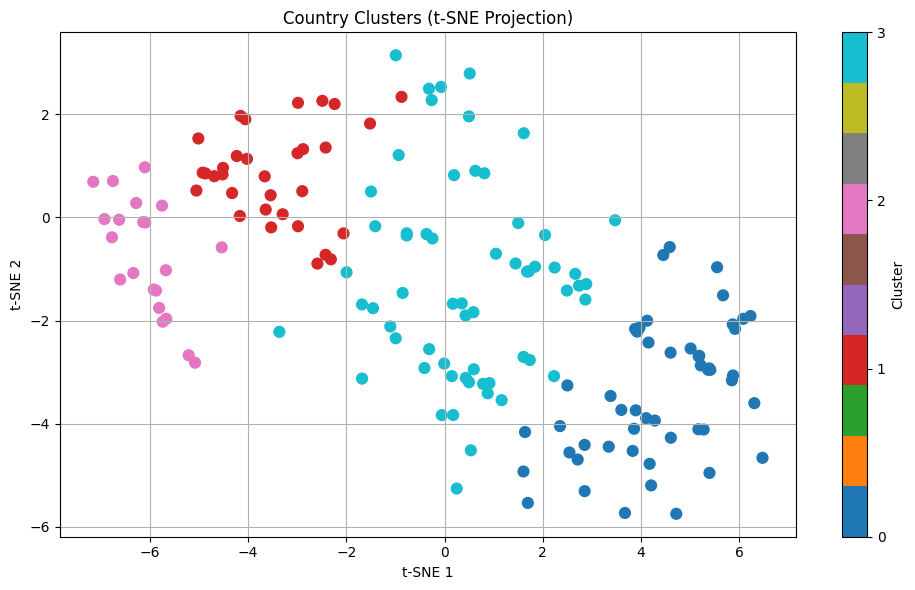

In [23]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=50, random_state=42)
X_tsne = tsne.fit_transform(features_normalized)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='tab10', s=60)
plt.title('Country Clusters (t-SNE Projection)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(scatter, ticks=range(k), label='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Combine country identifiers with cluster labels
identifiers_with_clusters = identifiers.copy()
identifiers_with_clusters['cluster'] = clusters

# Group by cluster and sample 10 countries from each
sampled_countries = (
    identifiers_with_clusters
    .groupby('cluster')
    .apply(lambda x: x.sample(n=min(10, len(x)))) 
    .reset_index(drop=True)
)

# Print countries by cluster
for cluster_id in sorted(sampled_countries['cluster'].unique()):
    countries = sampled_countries[sampled_countries['cluster'] == cluster_id]['country_name'].tolist()
    print(f"\n🌍 10 countries from Cluster {cluster_id}:")
    print("\n".join(countries))



🌍 10 countries from Cluster 0:
Israel
Poland
Cyprus
New Zealand
Netherlands
Estonia
Bulgaria
Belgium
Latvia
Croatia

🌍 10 countries from Cluster 1:
Russia
Uganda
Somaliland
Burundi
Iran
Zimbabwe
Mozambique
El Salvador
Comoros
Türkiye

🌍 10 countries from Cluster 2:
Oman
Chad
Hong Kong
Cuba
South Sudan
Saudi Arabia
Mali
Laos
Ethiopia
Syria

🌍 10 countries from Cluster 3:
Albania
Kenya
Zambia
Kuwait
Senegal
Dominican Republic
Montenegro
Mongolia
Bolivia
Maldives


C:\Users\danyi\AppData\Local\Temp\ipykernel_12020\767403493.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(10, len(x))))  # avoids error if <10 in group
